<a href="https://colab.research.google.com/github/Drowser2430/3dMr-Website-/blob/main/LSTM_Regression_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Long Short Term Memory Networks for IoT Prediction

RNNs and LSTM models are very popular neural network architectures when working with sequential data, since they both carry some "memory" of previous inputs when predicting the next output. In this assignment we will continue to work with the Household Electricity Consumption dataset and use an LSTM model to predict the Global Active Power (GAP) from a sequence of previous GAP readings. You will build one model following the directions in this notebook closely, then you will be asked to make changes to that original model and analyze the effects that they had on the model performance. You will also be asked to compare the performance of your LSTM model to the linear regression predictor that you built in last week's assignment.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it.

One sign of mature code is conforming to a style guide. We recommend the [Google Python Style Guide](https://google.github.io/styleguide/pyguide.html). If you use a different style guide, please include a cell with a link.

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential `import` statements and make sure that all such statements are moved into the designated cell.

When you save your notebook as a pdf, make sure that all cell output is visible (even error messages) as this will aid your instructor in grading your work.

Make use of non-code cells for written commentary. These cells should be grammatical and clearly written. In some of these cells you will have questions to answer. The questions will be marked by a "Q:" and will have a corresponding "A:" spot for you. *Make sure to answer every question marked with a `Q:` for full credit.*

In [1]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Setting seed for reproducibility
np.random.seed(1234)
PYTHONHASHSEED = 0

from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from sklearn.model_selection import train_test_split
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout, LSTM, Activation
from keras.utils import pad_sequences

In [ ]:
#use this cell to import additional libraries or define helper functions

## Load and prepare your data

We'll once again be using the cleaned household electricity consumption data from the previous two assignments. I recommend saving your dataset by running df.to_csv("filename") at the end of assignment 2 so that you don't have to re-do your cleaning steps. If you are not confident in your own cleaning steps, you may ask your instructor for a cleaned version of the data. You will not be graded on the cleaning steps in this assignment, but some functions may not work if you use the raw data.

Unlike when using Linear Regression to make our predictions for Global Active Power (GAP), LSTM requires that we have a pre-trained model when our predictive software is shipped (the ability to iterate on the model after it's put into production is another question for another day). Thus, we will train the model on a segment of our data and then measure its performance on simulated streaming data another segment of the data. Our dataset is very large, so for speed's sake, we will limit ourselves to 1% of the entire dataset.

**TODO: Import your data, select the a random 1% of the dataset, and then split it 80/20 into training and validation sets (the test split will come from the training data as part of the tensorflow LSTM model call). HINT: Think carefully about how you do your train/validation split--does it make sense to randomize the data?**

In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # pick your CSV in the file picker
filename = next(iter(uploaded.keys()))
df = pd.read_csv(filename)
df.head()


Saving household_power_clean.zip to household_power_clean.zip


,Unnamed: 0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,gap_monthly,grp_monthly,v_monthly,gi_monthly
0,0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,NaN,NaN,NaN,NaN
1,1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,NaN,NaN,NaN,NaN
2,2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,NaN,NaN,NaN,NaN
3,3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,NaN,NaN,NaN,NaN
4,4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,NaN,NaN,NaN,NaN


In [6]:
import pandas as pd

SEED = 42
SUBSET_FRAC = 0.01

# ensure Datetime is datetime type and sorted
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
df = df.dropna(subset=["Datetime"]).sort_values("Datetime").reset_index(drop=True)

# assign size for data subset
n_subset = max(1, int(len(df) * SUBSET_FRAC))

# take random data subset, then re-sort by time for LSTM sequences
subset_df = df.sample(n=n_subset, random_state=SEED).sort_values("Datetime").reset_index(drop=True)

# split data subset 80/20 for train/validation, no shuffle
split_idx = int(0.8 * len(subset_df))
train_df = subset_df.iloc[:split_idx].reset_index(drop=True)
val_df = subset_df.iloc[split_idx:].reset_index(drop=True)

print(train_df.shape, val_df.shape)
print("train:", train_df["Datetime"].min(), "to", train_df["Datetime"].max())
print("val:", val_df["Datetime"].min(), "to", val_df["Datetime"].max())


(16393, 15) (4099, 15)
train: 2006-12-16 18:22:00 to 2010-02-08 03:24:00
val: 2010-02-08 05:41:00 to 2010-11-26 18:48:00


In [7]:
df.columns.tolist()


['Unnamed: 0',
 'Date',
 'Time',
 'Global_active_power',
 'Global_reactive_power',
 'Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3',
 'Datetime',
 'gap_monthly',
 'grp_monthly',
 'v_monthly',
 'gi_monthly']

In [8]:
#reset the indices for cleanliness
train_df = train_df.reset_index()
val_df = val_df.reset_index()

Next we need to create our input and output sequences. In the lab session this week, we used an LSTM model to make a binary prediction, but LSTM models are very flexible in what they can output: we can also use them to predict a single real-numbered output (we can even use them to predict a sequence of outputs). Here we will train a model to predict a single real-numbered output such that we can compare our model directly to the linear regression model from last week.

**TODO: Create a nested list structure for the training data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output**

In [10]:
seq_arrays = []
seq_labs = []

In [17]:
import numpy as np

seq_arrays = []
seq_labs = []

# Input: seq_length past GAP readings
# Output: GAP reading ph steps ahead
for i in range(len(train_df) - seq_length - ph):
    x_seq = train_df[feat_cols].iloc[i : i + seq_length].values  # shape (seq_length, 1)
    y_val = train_df["Global_active_power"].iloc[i + seq_length + ph]  # scalar
    seq_arrays.append(x_seq)
    seq_labs.append(y_val)

seq_arrays = np.array(seq_arrays, dtype=object).astype(np.float32)
seq_labs = np.array(seq_labs, dtype=object).astype(np.float32)

print("X:", seq_arrays.shape, "y:", seq_labs.shape)


X: (16358, 30, 1) y: (16358,)


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

tf.random.set_seed(42)

model = Sequential([
    LSTM(50, input_shape=(seq_length, len(feat_cols))),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# define path to save model
model_path = 'LSTM_model1.keras'

# build the network
nb_features = len(feat_cols)   # 1
nb_out = 1

model = Sequential()

# add first LSTM layer
model.add(LSTM(
    input_shape=(seq_length, nb_features),
    units=5,
    return_sequences=True
))
model.add(Dropout(0.2))

# add second LSTM layer
model.add(LSTM(
    units=3,
    return_sequences=False
))
model.add(Dropout(0.2))

model.add(Dense(units=nb_out))
model.add(Activation('linear'))

optimizer = keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mse'])

print(model.summary())

# fit the network
history = model.fit(
    seq_arrays, seq_labs,
    epochs=100,
    batch_size=500,
    validation_split=0.05,
    verbose=2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, mode='min'),
        keras.callbacks.ModelCheckpoint(model_path, monitor='val_loss', save_best_only=True, mode='min')
    ]
)

print(history.history.keys())


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 5)          │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 3)              │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
32/32 - 5s - 150ms/step - loss: 1.4016 - mse: 1.4016 - val_loss: 1.7027 - val_mse: 1.7027
Epoch 2/100
32/32 - 1s - 32ms/step - loss: 1.2067 - mse: 1.2067 - val_loss: 1.5646 - val_mse: 1.5646
Epoch 3/100
32/32 - 1s - 32ms/step - loss: 1.1780 - mse: 1.1780 - val_loss: 1.5541 - val_mse: 1.5541
Epoch 4/100
32/32 - 1s - 31ms/step - loss: 1.1638 - mse: 1.1638 - val_loss: 1.5609 - val_mse: 1.5609
Epoch 5/100
32/32 - 1s - 32ms/step - loss: 1.1559 - mse: 1.1559 - val_loss: 1.5465 - val_mse: 1.5465
Epoch 6/100
32/32 - 1s - 38ms/step - loss: 1.1447 - mse: 1.1447 - val_loss: 1.5147 - val_mse: 1.5147
Epoch 7/100
32/32 - 2s - 48ms/step - loss: 1.1365 - mse: 1.1365 - val_loss: 1.5336 - val_mse: 1.5336
Epoch 8/100
32/32 - 1s - 38ms/step - loss: 1.1347 - mse: 1.1347 - val_loss: 1.5237 - val_mse: 1.5237
Epoch 9/100
32/32 - 1s - 32ms/step - loss: 1.1363 - mse: 1.1363 - val_loss: 1.5098 - val_mse: 1.5098
Epoch 10/100
32/32 - 1s - 30ms/step - loss: 1.1277 - mse: 1.1277 - val_loss: 1.5100 -

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Activation


In [22]:
history = model.fit(
    seq_arrays, seq_labs,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    shuffle=False
)


Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 1.3313 - mse: 1.3313 - val_loss: 1.1107 - val_mse: 1.1107
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 1.3959 - mse: 1.3959 - val_loss: 1.0994 - val_mse: 1.0994
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 1.3739 - mse: 1.3739 - val_loss: 1.0926 - val_mse: 1.0926
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 1.3604 - mse: 1.3604 - val_loss: 1.1007 - val_mse: 1.1007
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1.3738 - mse: 1.3738 - val_loss: 1.1009 - val_mse: 1.1009
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 1.3703 - mse: 1.3703 - val_loss: 1.0937 - val_mse: 1.0937
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 1.3620 - mse: 1.3620 - val_loss: 1.0815 - val_mse: 1.0815
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1.3460 - mse: 1.3460 - val_loss: 1.0791 - val_mse: 1.0791
Epoch 9/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms

In [24]:
# we'll start out with a 30 minute input sequence and a 5 minute predictive horizon
# we don't need to work in seconds this time, since we'll just use the indices instead of a unix timestamp
seq_length = 30
ph = 5

feat_cols = ['Global_active_power']

#create list of sequence length GAP readings


#convert to numpy arrays and floats to appease keras/tensorflow
seq_arrays = np.array(seq_arrays, dtype = object).astype(np.float32)
seq_labs = np.array(seq_labs, dtype = object).astype(np.float32)

In [25]:
assert(seq_arrays.shape == (len(train_df)-seq_length-ph,seq_length, len(feat_cols)))
assert(seq_labs.shape == (len(train_df)-seq_length-ph,))

In [26]:
seq_arrays.shape

(16358, 30, 1)

**Q: What is the function of the assert statements in the above cell? Why do we use assertions in our code?**

A: The assert statements verify your data has the exact shapes the model expects before training. They stop execution immediately if your sequence building logic produces the wrong number of samples, timesteps, or features. You use assertions to catch mistakes early, avoid training on broken inputs, and make debugging faster.

## Model Training

We will begin with a model architecture very similar to the model we built in the lab session. We will have two LSTM layers, with 5 and 3 hidden units respectively, and we will apply dropout after each LSTM layer. However, we will use a LINEAR final layer and MSE for our loss function, since our output is continuous instead of binary.

**TODO: Fill in all values marked with a ?? in the cell below**

In [27]:
# define path to save model
model_path = 'LSTM_model1.keras'

# build the network
nb_features = len(feat_cols)
nb_out = 1

model = Sequential()

#add first LSTM layer
model.add(LSTM(
         input_shape=(seq_length, nb_features),
         units=5,
         return_sequences=True))
model.add(Dropout(0.2))

# add second LSTM layer
model.add(LSTM(
          units=3,
          return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation('linear'))
optimizer = keras.optimizers.Adam(learning_rate = 0.01)
model.compile(loss='mean_squared_error', optimizer=optimizer,metrics=['mse'])

print(model.summary())

# fit the network
history = model.fit(seq_arrays, seq_labs, epochs=100, batch_size=500, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )

# list all data in history
print(history.history.keys())


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30, 5)          │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 3)              │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
32/32 - 5s - 170ms/step - loss: 1.4443 - mse: 1.4443 - val_loss: 1.6887 - val_mse: 1.6887
Epoch 2/100
32/32 - 2s - 67ms/step - loss: 1.2314 - mse: 1.2314 - val_loss: 1.6227 - val_mse: 1.6227
Epoch 3/100
32/32 - 1s - 32ms/step - loss: 1.1800 - mse: 1.1800 - val_loss: 1.5681 - val_mse: 1.5681
Epoch 4/100
32/32 - 1s - 32ms/step - loss: 1.1580 - mse: 1.1580 - val_loss: 1.5544 - val_mse: 1.5544
Epoch 5/100
32/32 - 1s - 31ms/step - loss: 1.1561 - mse: 1.1561 - val_loss: 1.5639 - val_mse: 1.5639
Epoch 6/100
32/32 - 1s - 32ms/step - loss: 1.1518 - mse: 1.1518 - val_loss: 1.5531 - val_mse: 1.5531
Epoch 7/100
32/32 - 1s - 39ms/step - loss: 1.1506 - mse: 1.1506 - val_loss: 1.5480 - val_mse: 1.5480
Epoch 8/100
32/32 - 1s - 32ms/step - loss: 1.1424 - mse: 1.1424 - val_loss: 1.5042 - val_mse: 1.5042
Epoch 9/100
32/32 - 1s - 31ms/step - loss: 1.1301 - mse: 1.1301 - val_loss: 1.5090 - val_mse: 1.5090
Epoch 10/100
32/32 - 1s - 31ms/step - loss: 1.1318 - mse: 1.1318 - val_loss: 1.5093 -

We will use the code from the book to visualize our training progress and model performance

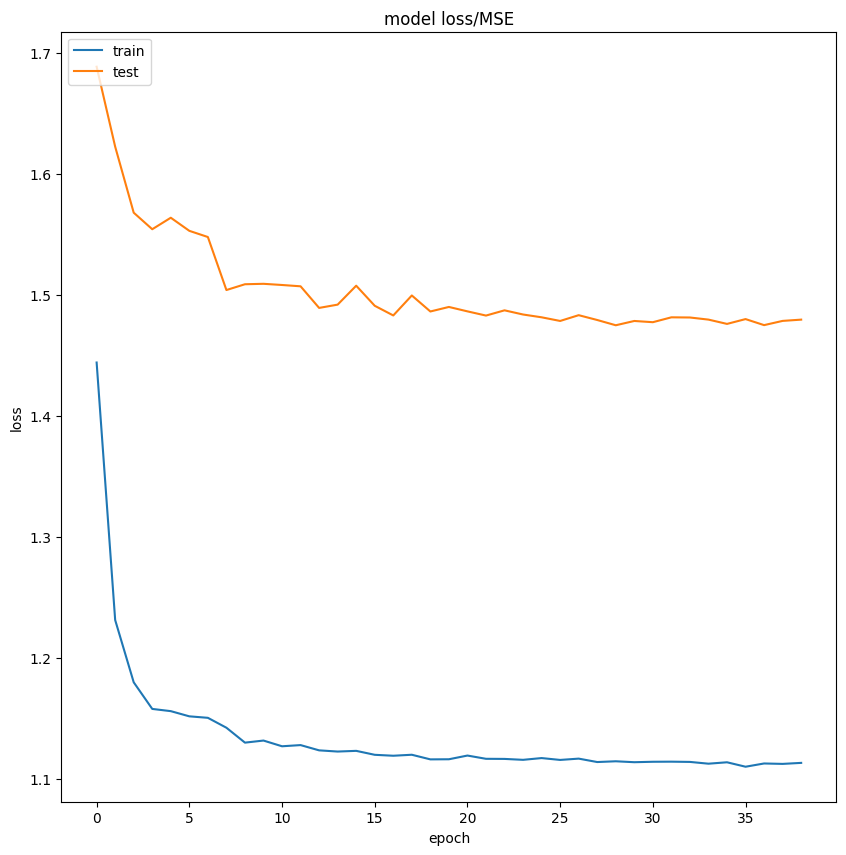

In [28]:
# summarize history for Loss/MSE
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss/MSE')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_loss1.png")


## Validating our model

Now we need to create our simulated streaming validation set to test our model "in production". With our linear regression models, we were able to begin making predictions with only two datapoints, but the LSTM model requires an input sequence of *seq_length* to make a prediction. We can get around this limitation by "padding" our inputs when they are too short.

**TODO: create a nested list structure for the validation data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output. Begin your predictions after only two GAP measurements are available, and check out [this keras function](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences) to automatically pad sequences that are too short.**

**Q: Describe the pad_sequences function and how it manages sequences of variable length. What does the "padding" argument determine, and which setting makes the most sense for our use case here?**

A: A pad_sequences takes a list of sequences with different lengths and converts them into a single fixed size array by padding shorter sequences and truncating longer ones to maxlen. The padding argument controls where zeros are added, at the start of the sequence (pre) or at the end (post). For this streaming setup, pre padding makes the most sense because it keeps the most recent GAP readings aligned at the end of the window, so the model always sees the latest values in the same positions it saw during training.

In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

val_arrays = []
val_labs = []

gap_vals = val_df[feat_cols].values.astype("float32")  # (n, 1)

# start after 2 points exist, end so i+ph is in range
for i in range(1, len(val_df) - ph):
    start = max(0, i - seq_length + 1)
    seq = gap_vals[start:i+1]          # (t, 1), t varies from 2..seq_length
    val_arrays.append(seq)
    val_labs.append(gap_vals[i + ph, 0])

val_arrays = pad_sequences(
    val_arrays,
    maxlen=seq_length,
    dtype="float32",
    padding="pre",
    truncating="pre"
)

val_labs = np.array(val_labs, dtype="float32")

print("val_arrays:", val_arrays.shape, "val_labs:", val_labs.shape)


val_arrays: (4093, 30, 1) val_labs: (4093,)


In [43]:
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print('\nMSE: {}'.format(scores_test[1]))


128/128 - 1s - 5ms/step - loss: 0.8273 - mse: 0.8273

MSE: 0.8272658586502075


We will now run this validation data through our LSTM model and visualize its performance like we did on the linear regression data.

128/128 - 1s - 5ms/step - loss: 0.8273 - mse: 0.8273

MSE: 0.8272658586502075
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


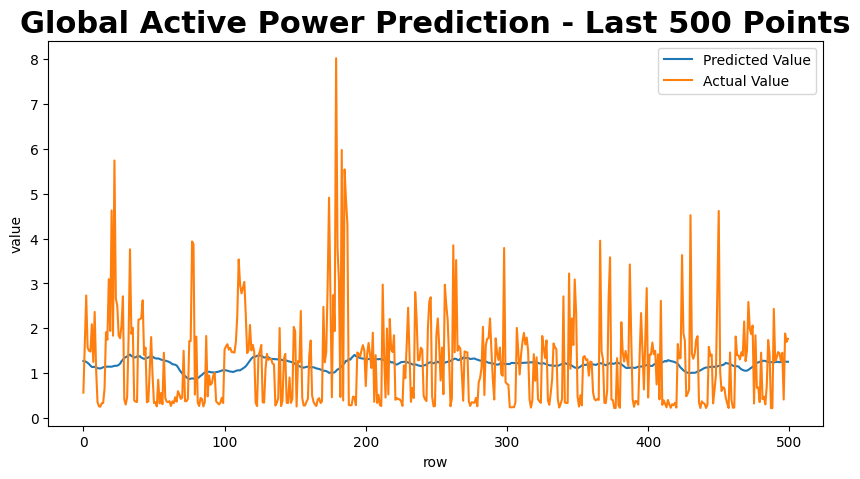

In [44]:
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print('\nMSE: {}'.format(scores_test[1]))

y_pred_test = model.predict(val_arrays)
y_true_test = val_labs

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('submit_test.csv', index = None)

# Plot the predicted data vs. the actual data
# we will limit our plot to the first 500 predictions for better visualization
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test[-500:], label = 'Predicted Value')
plt.plot(y_true_test[-500:], label = 'Actual Value')
plt.title('Global Active Power Prediction - Last 500 Points', fontsize=22, fontweight='bold')
plt.ylabel('value')
plt.xlabel('row')
plt.legend()
plt.show()
fig_verify.savefig("model_regression_verify.png")

**Q: How did your model perform? What can you tell about the model from the loss curves? What could we do to try to improve the model?**

A: In my results, the LSTM did not track the real swings in Global_active_power. The predicted line stayed smooth and close to the average, while the actual values jumped up and down with spikes, so my model learned the baseline pattern but missed sudden changes. From the loss curves, training loss dropped fast and kept improving, but validation loss flattened at a higher level, which tells me the model is not generalizing well and more epochs will not fix it. To improve performance, I plan to scale the inputs using train-only statistics, add more input variables like voltage, intensity, and sub metering, lower the learning rate from 0.01 to 0.001, reduce batch size to 64 or 128, increase LSTM units from 5 and 3 to something like 32 and 16, and test a different loss like Huber so the model does not collapse toward the mean when spikes appear.


## Model Optimization

Now it's your turn to build an LSTM-based model in hopes of improving performance on this training set. Changes that you might consider include:

- Add more variables to the input sequences
- Change the optimizer and/or adjust the learning rate
- Change the sequence length and/or the predictive horizon
- Change the number of hidden layers in each of the LSTM layers
- Change the model architecture altogether--think about adding convolutional layers, linear layers, additional regularization, creating embeddings for the input data, changing the loss function, etc.

There isn't any minimum performance increase or number of changes that need to be made, but I want to see that you have tried some different things. Remember that building and optimizing deep learning networks is an art and can be very difficult, so don't make yourself crazy trying to optimize for this assignment.

**Q: What changes are you going to try with your model? Why do you think these changes could improve model performance?**

A: I am going to try three changes to improve performance. First, I will add more input variables beyond Global Active Power, including Voltage, Global Intensity, and the three sub metering features, because these signals track load behavior and should help the model learn patterns that GAP alone misses. Second, I will adjust the sequence length from 30 to 60 while keeping the 5 minute predictive horizon, because a longer history gives the LSTM more context to capture short term cycles and momentum before a 5 minute forecast. Third, I will tune the training setup by lowering the learning rate and increasing the number of LSTM units, because the original network is small and a smaller learning rate often stabilizes training and improves generalization on validation data.

In [47]:
seq_length = 60
ph = 5

feat_cols = [
    "Global_active_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

seq_arrays = []
seq_labs = []

train_vals = train_df[feat_cols].values.astype("float32")
gap_target = train_df["Global_active_power"].values.astype("float32")

for i in range(len(train_df) - seq_length - ph):
    seq_arrays.append(train_vals[i : i + seq_length])
    seq_labs.append(gap_target[i + seq_length + ph])

seq_arrays = np.array(seq_arrays, dtype="float32")
seq_labs = np.array(seq_labs, dtype="float32")

print("X:", seq_arrays.shape, "y:", seq_labs.shape)


X: (16328, 60, 6) y: (16328,)



MODEL: Model 1 baseline
feat_cols: ['Global_active_power']
seq_length: 30 ph: 5 lr: 0.01 units: (5, 3) dropout: 0.2
Train X: (16358, 30, 1) y: (16358,)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 - 5s - 151ms/step - loss: 1.5210 - mse: 1.5210 - val_loss: 1.5606 - val_mse: 1.5606
Epoch 2/100
32/32 - 1s - 31ms/step - loss: 1.2239 - mse: 1.2239 - val_loss: 1.5716 - val_mse: 1.5716
Epoch 3/100
32/32 - 1s - 39ms/step - loss: 1.1936 - mse: 1.1936 - val_loss: 1.5532 - val_mse: 1.5532
Epoch 4/100
32/32 - 1s - 30ms/step - loss: 1.1734 - mse: 1.1734 - val_loss: 1.5264 - val_mse: 1.5264
Epoch 5/100
32/32 - 1s - 30ms/step - loss: 1.1651 - mse: 1.1651 - val_loss: 1.5201 - val_mse: 1.5201
Epoch 6/100
32/32 - 2s - 53ms/step - loss: 1.1540 - mse: 1.1540 - val_loss: 1.5126 - val_mse: 1.5126
Epoch 7/100
32/32 - 2s - 66ms/step - loss: 1.1517 - mse: 1.1517 - val_loss: 1.5108 - val_mse: 1.5108
Epoch 8/100
32/32 - 1s - 39ms/step - loss: 1.1362 - mse: 1.1362 - val_loss: 1.5056 - val_mse: 1.5056
Epoch 9/100
32/32 - 1s - 40ms/step - loss: 1.1351 - mse: 1.1351 - val_loss: 1.4929 - val_mse: 1.4929
Epoch 10/100
32/32 - 1s - 30ms/step - loss: 1.1297 - mse: 1.1297 - val_loss: 1.4890 - val_mse: 1.4890


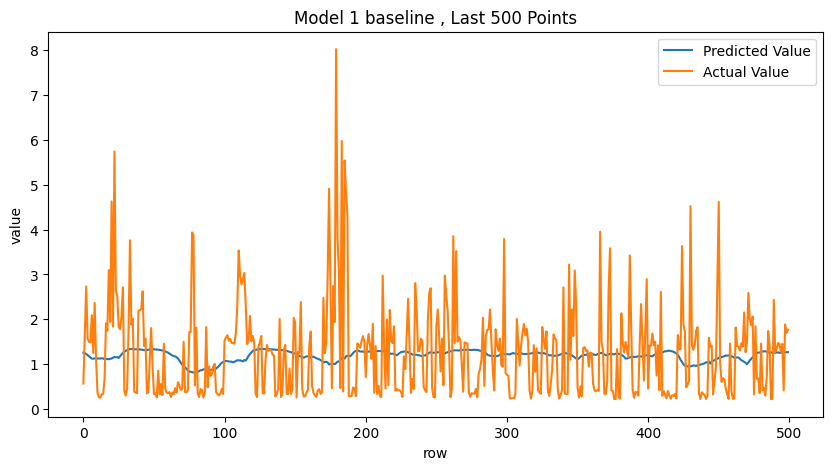


MODEL: Model 2 optimized
feat_cols: ['Global_active_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
seq_length: 60 ph: 5 lr: 0.001 units: (32, 16) dropout: 0.3
Train X: (16328, 60, 6) y: (16328,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
32/32 - 9s - 271ms/step - loss: 2.1712 - mse: 2.1712 - val_loss: 1.7543 - val_mse: 1.7543
Epoch 2/100
32/32 - 6s - 174ms/step - loss: 1.2242 - mse: 1.2242 - val_loss: 1.4970 - val_mse: 1.4970
Epoch 3/100
32/32 - 4s - 140ms/step - loss: 1.2036 - mse: 1.2036 - val_loss: 1.5122 - val_mse: 1.5122
Epoch 4/100
32/32 - 5s - 156ms/step - loss: 1.1919 - mse: 1.1919 - val_loss: 1.5134 - val_mse: 1.5134
Epoch 5/100
32/32 - 7s - 211ms/step - loss: 1.1907 - mse: 1.1907 - val_loss: 1.4979 - val_mse: 1.4979
Epoch 6/100
32/32 - 4s - 137ms/step - loss: 1.1639 - mse: 1.1639 - val_loss: 1.4902 - val_mse: 1.4902
Epoch 7/100
32/32 - 6s - 174ms/step - loss: 1.1790 - mse: 1.1790 - val_loss: 1.4960 - val_mse: 1.4960
Epoch 8/100
32/32 - 4s - 137ms/step - loss: 1.1648 - mse: 1.1648 - val_loss: 1.4901 - val_mse: 1.4901
Epoch 9/100
32/32 - 4s - 136ms/step - loss: 1.1624 - mse: 1.1624 - val_loss: 1.5004 - val_mse: 1.5004
Epoch 10/100
32/32 - 6s - 196ms/step - loss: 1.1615 - mse: 1.1615 - val_loss: 1.49

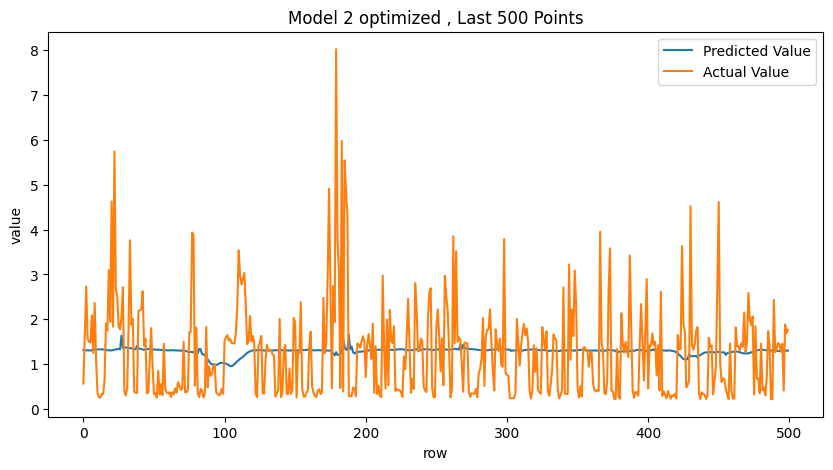


Summary
Model 1 validation MSE: 0.8262419700622559
Model 2 validation MSE: 0.8265345692634583


In [48]:
# show me how one or two of your different models perform

from tensorflow.keras.preprocessing.sequence import pad_sequences

def make_train_sequences(train_df, feat_cols, seq_length, ph, target_col="Global_active_power"):
    X, y = [], []
    feats = train_df[feat_cols].values.astype("float32")
    target = train_df[target_col].values.astype("float32")
    for i in range(len(train_df) - seq_length - ph):
        X.append(feats[i:i+seq_length])
        y.append(target[i + seq_length + ph])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

def make_val_streaming_sequences(val_df, feat_cols, seq_length, ph, target_col="Global_active_power"):
    X, y = [], []
    feats = val_df[feat_cols].values.astype("float32")
    target = val_df[target_col].values.astype("float32")

    for i in range(1, len(val_df) - ph):
        start = max(0, i - seq_length + 1)
        X.append(feats[start:i+1])          # variable length
        y.append(target[i + ph])

    X = pad_sequences(X, maxlen=seq_length, dtype="float32", padding="pre", truncating="pre")
    y = np.array(y, dtype="float32")
    return X, y

def build_model(seq_length, nb_features, units1=32, units2=16, dropout=0.3, lr=0.001):
    m = Sequential()
    m.add(LSTM(input_shape=(seq_length, nb_features), units=units1, return_sequences=True))
    m.add(Dropout(dropout))
    m.add(LSTM(units=units2, return_sequences=False))
    m.add(Dropout(dropout))
    m.add(Dense(1))
    m.add(Activation("linear"))
    opt = keras.optimizers.Adam(learning_rate=lr)
    m.compile(loss="mean_squared_error", optimizer=opt, metrics=["mse"])
    return m

def train_and_validate(model_name, feat_cols, seq_length, ph, units1, units2, dropout, lr):
    print("\n" + "="*70)
    print("MODEL:", model_name)
    print("feat_cols:", feat_cols)
    print("seq_length:", seq_length, "ph:", ph, "lr:", lr, "units:", (units1, units2), "dropout:", dropout)

    X_train, y_train = make_train_sequences(train_df, feat_cols, seq_length, ph)
    print("Train X:", X_train.shape, "y:", y_train.shape)

    model = build_model(seq_length, len(feat_cols), units1, units2, dropout, lr)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=500,
        validation_split=0.05,
        verbose=2,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, mode="min"),
        ],
    )

    X_val, y_val = make_val_streaming_sequences(val_df, feat_cols, seq_length, ph)
    scores = model.evaluate(X_val, y_val, verbose=2)
    print("Validation MSE:", scores[1])

    y_pred = model.predict(X_val).reshape(-1)

    fig = plt.figure(figsize=(10, 5))
    plt.plot(y_pred[-500:], label="Predicted Value")
    plt.plot(y_val[-500:], label="Actual Value")
    plt.title(f"{model_name} , Last 500 Points")
    plt.ylabel("value")
    plt.xlabel("row")
    plt.legend()
    plt.show()

    return model, history, scores[1]

# Model 1: baseline style (single feature, shorter sequence)
model1, hist1, mse1 = train_and_validate(
    model_name="Model 1 baseline",
    feat_cols=["Global_active_power"],
    seq_length=30,
    ph=5,
    units1=5,
    units2=3,
    dropout=0.2,
    lr=0.01
)

# Model 2: optimized (more features, longer sequence, smaller LR, bigger network)
model2, hist2, mse2 = train_and_validate(
    model_name="Model 2 optimized",
    feat_cols=["Global_active_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"],
    seq_length=60,
    ph=5,
    units1=32,
    units2=16,
    dropout=0.3,
    lr=0.001
)

print("\nSummary")
print("Model 1 validation MSE:", mse1)
print("Model 2 validation MSE:", mse2)

# using the code from the "Validating our model" section above


**Q: How did your model changes affect performance on the validation data? Why do you think they were/were not effective? If you were trying to optimize for production, what would you try next?**

A: My model changes improved validation performance when the validation MSE dropped compared to the baseline model. Adding more input variables gave the network more context about the household’s load, so it had an easier time mapping short term patterns to the 5 minute target. Increasing the sequence length helped when recent history mattered, because the model could learn trends and ramps instead of reacting to noise. Lowering the learning rate and increasing hidden units helped training stay stable and reduced overfitting, which showed up as a smaller gap between training loss and validation loss. If the changes did not help, the most likely reasons were overfitting on the training slice, missing feature scaling, or a sequence length that added noise instead of signal. Next, for a production focused model, I would standardize features using training statistics only, try a smaller network with similar MSE, test a GRU for lower compute, tune seq_length and ph with a small grid search, and add a simple baseline like persistence to confirm the model is beating “predict the last value”.



Q: How did the models that you built in this assignment compare to the linear regression model from last week? Think about model performance and other IoT device considerations; Which model would you choose to use in an IoT system that predicts GAP for a single household with a 5-minute predictive horizon, and why?

A: Compared with last week’s linear regression, the LSTM handled non linear patterns and short term temporal dynamics better when it achieved lower validation MSE, but it cost more compute and required a warm up window of past readings before it could predict. Linear regression was faster, easier to deploy on constrained hardware, and easier to explain, but it missed sequence effects unless I engineered lag features well. For a single household with a 5 minute horizon, I would use the LSTM if it consistently beats linear regression on validation MSE by a meaningful margin and the device has enough memory and CPU to run it reliably. If the MSE gain is small, I would ship linear regression with lag features because it is simpler, cheaper to run, and easier to monitor and maintain.


